# pymor.timestepping

> Extended functionality for [pyMOR](https://pymor.org/) time steppers

In [23]:
#| default_exp pymor.timestepping

## Imports

In [24]:
#| export
import time

from fastcore.basics import patch
import ipywidgets as widgets

import numpy as np
from scikits.odes.sundials import cvode
import scipy.sparse as sps
import pymor
from pymor.algorithms.to_matrix import to_matrix
from pymor.algorithms.simplify import expand
from pymor.algorithms.timestepping import TimeStepper
from pymor.basic import LincombOperator

from pymor.algorithms.simplify import ExpandRules, expand, ContractRules, contract
from pymor.algorithms.rules import match_class, RuleTable


from pylgs.utilities.sparse import sparse2d_identity, spilu, restrict_bandwidth
from pylgs.pymor.vectorarrays import *
from pylgs.pymor.operators import *
# from pymor.basic import *

In [25]:
from xarray import Coordinates
from pymor.basic import RectDomain, ConstantFunction, ExpressionFunction, StationaryProblem, \
    discretize_stationary_cg, thermal_block_problem, InstationaryProblem, discretize_instationary_cg, \
    NumpyMatrixOperator, ExpressionParameterFunctional, Parameters, InstationaryModel, Mu

In [26]:
#| export
try:
    @pymor.defaults('cvode_bdf_rtol', 'cvode_bdf_atol', 'cvode_bdf_max_steps', 'cvode_stiff_switching_t_switch')
    def cvode_solver_options(
        cvode_bdf_rtol=1e-3,
        cvode_bdf_atol=1e-6,
        cvode_bdf_max_steps=100000,
        cvode_bdf_inflection_times=None,
        cvode_stiff_switching_t_switch=1e-7
    ):
        opts = {
            'cvode_bdf': {'type': 'cvode_bdf', 'atol': cvode_bdf_atol, 'rtol': cvode_bdf_rtol, 'max_steps': cvode_bdf_max_steps, 'inflection_times': cvode_bdf_inflection_times},
            'cvode_stiff_switching': {'type': 'cvode_stiff_switching', 't_switch': cvode_stiff_switching_t_switch}
        }
        return opts
except ValueError: pass

## API

### solve -

In [27]:
#| export
@patch
def solve(self:TimeStepper, initial_time, end_time, initial_data, operator, rhs=None, mass=None, mu=None, num_values=None):
    """Apply time-stepper to the equation.

    The equation is of the form ::

        M(mu) * d_t u + A(u, mu, t) = F(mu, t),
                         u(mu, t_0) = u_0(mu).

    Parameters
    ----------
    initial_time
        The time at which to begin time-stepping.
    end_time
        The time until which to perform time-stepping.
    initial_data
        The solution vector at initial_timeinitial_time.
    operator
        The |Operator| A.
    rhs
        The right-hand side F (either |VectorArray| of length 1 or |Operator| with
        source.dim == 1source.dim == 1). If NoneNone, zero right-hand side is assumed.
    mass
        The |Operator| M. If NoneNone, the identity operator is assumed.
    mu
        |Parameter values| for which operatoroperator and rhsrhs are evaluated. The current
        time is added to mumu with key tt.
    num_values
        The number of returned vectors of the solution trajectory. If NoneNone, each
        intermediate vector that is calculated is returned.

    Returns
    -------
    |VectorArray| containing the solution trajectory.
    """
    try:
        num_time_steps = self.estimate_time_step_count(initial_time, end_time)
    except NotImplementedError:
        num_time_steps = 0
    iterator = self.iterate(initial_time, end_time, initial_data, operator, rhs=rhs, mass=mass, mu=mu,
                            num_values=num_values)
    iterator = list(iterator)
    if isinstance(iterator[0], XarrayVectorArray):
        return iterator[0]
    U = operator.source.empty(reserve=num_values if num_values else num_time_steps + 1)
    t = []
    for U_n, t_n in iterator:
        U.append(U_n)
        t.append(t_n)
    try: return operator.source.from_numpy(U.to_numpy(), l={"Time": t})
    except: return U

### AdamsTimeStepper -

In [28]:
#|export
def init_progress_widget(initial_time, end_time):
    progress = widgets.FloatProgress(
        value=initial_time,
        min=initial_time,
        max=end_time,
        bar_style='info',
        orientation='horizontal'
    )
    step_size = widgets.Label()
    widget = widgets.HBox([progress, step_size])
    display(widget)
    return widget

In [29]:
#|export
def tick(): return time.time() * 1000

In [30]:
#|export
def update_progress_widget(widget, tock, t, last_t):
    newtick = tick()
    if newtick - tock < 10: return tock
    widget.children[0].value = t
    widget.children[1].value = f'{t - last_t:1.1e}'
    return newtick

In [31]:
#|export
def init_cvode(cvode_rhs, num_values):
    return cvode.CVODE(cvode_rhs, lmm_type='Adams', nonlinsolver='fixedpoint', max_steps=1000000, one_step_compute=num_values is None)

In [32]:
#|export
def solve_cvode(solver, t_list, initial_data):
    return solver.solve(t_list, initial_data.to_numpy().T[0])

In [33]:
#| export
class AdamsTimeStepper(TimeStepper):
    def __init__(self):
        self.__auto_init(locals())
        
    def iterate(self, initial_time, end_time, initial_data, operator, rhs=None, mass=None, mu=None, num_values=None):

        def cvode_rhs(t, y, ydot):
            y = operator.source.from_numpy(y)
            np.copyto(ydot, rhs.as_range_array().to_numpy().ravel() - operator.apply(y, mu.at_time(t=t)).to_numpy().ravel())

        self._solver = cvode.CVODE(
            cvode_rhs, 
            lmm_type='Adams', 
            nonlinsolver='fixedpoint', 
            max_steps=1000000, 
            one_step_compute=True
        )
        min_reportable_step = (end_time - initial_time)/num_values
        progress = init_progress_widget(initial_time, end_time)
        tock = tick()
        y = [self._solver.init_step(initial_time, initial_data.to_numpy().T[0]).values.y]
        t = [initial_time]
        last_t = initial_time
        while t[-1] < end_time:
            values = self._solver.step(end_time).values
            tock = update_progress_widget(progress, tock, values.t, last_t)
            last_t = values.t
            if values.t - t[-1] < min_reportable_step: continue
            t.append(values.t)
            y.append(values.y)
        t = np.array(t)
        y = np.array(y)
        progress.close()
        
        if isinstance(operator.source, XarrayVectorSpace):
            return [operator.source.from_numpy(y, extended_coord_data={'Time': t})]
        return ((operator.source.from_numpy(u), t) for u, t in zip(y, t))
            
        # self._solver = init_cvode(cvode_rhs, num_values)
        # t_list = np.linspace(initial_time, end_time, num_values)
        # sol = solve_cvode(self._solver, t_list, initial_data)
        # progress.close()
        # if isinstance(operator.source, XarrayVectorSpace):
        #     return [operator.source.from_numpy(sol.values.y, extended_coord_data={'Time': t_list})]
        # return ((operator.source.from_numpy(u), t) for u, t in zip(sol.values.y, t_list))

#### Example 2

In [34]:
dof = Coordinates({'dof': ('dof', ['x', 'v'], {'long_name': "Degrees of freedom"})})

space = XarrayVectorSpace(dof)

A = XarrayMatrixOperator(np.array([[0., -1.], [1., 0]]), source=space, range=space)
B = XarrayMatrixOperator(np.array([[0., 0.], [0., 1.]]), source=space, range=space)
operator = LincombOperator(
    [A, B], 
    [
        ExpressionParameterFunctional("w0**2", Parameters({'w0': 1})), 
        ExpressionParameterFunctional("c", Parameters({'c': 1}))
    ]
)
rhs = space.from_numpy(np.array([[.1], [0.]]))
initial_data = space.from_numpy(np.array([1., 0.]))
T = 100

model = InstationaryModel(T, initial_data, operator, rhs, time_stepper=AdamsTimeStepper(), num_values=100)

mu = dict(c=.1, w0="sin(t)")
mu = model.parameters.parse(mu)

In [35]:
sol = model.solve(dict(c=.1, w0="sin(t+.001)"))

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

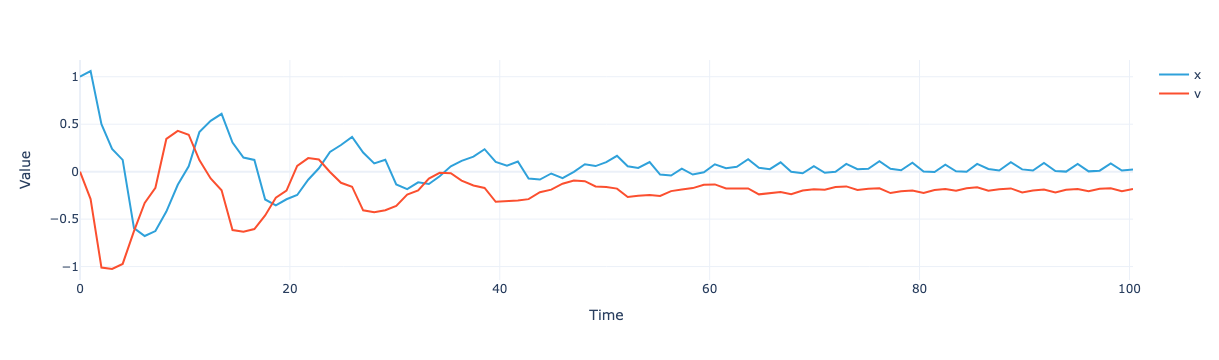

In [36]:
sol.visualize()

#### Example 1

In [37]:
# domain = RectDomain([[0.,0.], [1.,1.]])
# diffusion = ConstantFunction(1, 2)
# rhs = ExpressionFunction('(sqrt( (x[0]-0.5)**2 + (x[1]-0.5)**2) <= 0.3) * 1.', 2)
# problem = StationaryProblem(
#    domain=domain,
#    diffusion=diffusion,
#    rhs=rhs,
# )
# m, data = discretize_stationary_cg(problem, diameter=1)

# p = thermal_block_problem([2,2])
# m, _ = discretize_stationary_cg(p, diameter=1)
# pp = InstationaryProblem(p, initial_data=ConstantFunction(0., 2), T=1.)
# mm, _ = discretize_instationary_cg(pp, nt=10, diameter=1)

# mm = mm.with_(time_stepper=AdamsTimeStepper(), num_values=200, operator=mm.operator, mass=None, output_functional=None)

# mm.solve({'diffusion': [.5, .6, .7, .8]});

# def numpy_to_xarray(op):
#     if isinstance(op, NumpyMatrixOperator): return XarrayMatrixOperator(op.matrix, source='elements', range='elements', name=op.name if op.name != 'NumpyMatrixOperator' else None)
#     if isinstance(op, LincombOperator): return LincombOperator([numpy_to_xarray(o) for o in op.operators], op.coefficients, name=op.name)
#     if isinstance(op, VectorOperator): return LincombOperator([numpy_to_xarray(o) for o in op.operators], op.coefficients, name=op.name)

# mm.operator

# range_space = numpy_to_xarray(mm.operator).range
# source_space = numpy_to_xarray(mm.operator).source

# mmm = mm.with_(
#     T=mm.T,
#     initial_data=source_space.from_numpy(mm.initial_data.array.to_numpy()),
#     operator=numpy_to_xarray(mm.operator),
#     rhs=range_space.from_numpy(mm.rhs.as_range_array().to_numpy()),
#     mass=None,
#     output_functional=None,
#     time_stepper=AdamsTimeStepper()
# )

# mmm.solve({'diffusion': [.5, .6, .7, .8]})

### BDFTimeStepper -

In [38]:
# #| export
# class BDFTimeStepper(TimeStepper):
#     def __init__(self):
#         # self.__auto_init(locals())
#         pass
        
#     def iterate(self, initial_time, end_time, initial_data, operator, rhs=None, mass=None, mu=None, num_values=None, solver_options=None):
#         options = cvode_solver_options()['cvode_bdf']
#         if solver_options:
#             options.update(solver_options)
#         progress = init_progress_widget(initial_time, end_time)
#         tock = tick()
#         last_t = 0
        
#         def cvode_rhs(t, y, ydot):
#             nonlocal tock, last_t
#             tock = update_progress_widget(progress, tock, t, last_t)
#             last_t = t
#             np.copyto(ydot, (-operator.assemble(mu.at_time(t=t)).apply(operator.source.from_numpy(y)) + rhs.as_range_array(mu.at_time(t=t))).to_numpy().T[0])

#         def preconditioner_setup(t, y, jok, jcurPtr, gamma, user_data):
#             """Generate P and do ILU decomposition."""
#             if jok:
#                 jcurPtr.value = False
#             else:
#                 user_data['approximate_jacobian'] = -to_matrix(operator.assemble(mu.at_time(t=t)))
#                 if operator.solver_options is not None and 'inverse' in operator.solver_options:
#                     user_data['approximate_jacobian'] = restrict_bandwidth(
#                         user_data['approximate_jacobian'], 
#                         operator.solver_options['inverse']['preconditioner_bandwidth']
#                     )
#                 jcurPtr.value = True
#             # Scale jacobian by -gamma, add identity matrix and do LU decomposition
#             p = -gamma*user_data['approximate_jacobian'] + sparse2d_identity(user_data['approximate_jacobian'].shape[0])
#             if sps.issparse(p): 
#                 p = p.tocsc()
#             else:
#                 p = sps.csc_array(p)
#             user_data['factored_preconditioner'] = spilu(p) # , permc_spec='NATURAL')
#             return 0

#         def preconditioner_solve(t, y, r, z, gamma, delta, lr, user_data):
#             """ Solve the block-diagonal system Pz = r. """
#             np.copyto(z, user_data['factored_preconditioner'].solve(r))
#             return 0              
        
#         self._solver = cvode.CVODE(
#             cvode_rhs,
#             lmm_type='BDF', 
#             nonlinsolver='newton', 
#             linsolver='spgmr',
#             precond_type='left',
#             prec_setupfn=preconditioner_setup, 
#             prec_solvefn=preconditioner_solve,
#             rtol=options['rtol'], 
#             atol=options['atol'], 
#             max_steps=options['max_steps'],
#             user_data={}
#         )
#         t_list = np.linspace(initial_time, end_time, num_values)
#         sol = self._solver.solve(t_list, initial_data.to_numpy().T[0])
#         progress.close()
#         if isinstance(operator.source, XarrayVectorSpace):
#             return [operator.source.from_numpy(sol.values.y, extended_coord_data={'Time': t_list})]
#         return ((operator.source.from_numpy(u), t) for u, t in zip(sol.values.y, t_list))

In [39]:
#| export
class BDFTimeStepper(TimeStepper):
    def __init__(self):
        # self.__auto_init(locals())
        pass
        
    def iterate(self, initial_time, end_time, initial_data, operator, rhs=None, mass=None, mu=None, num_values=None):
        options = cvode_solver_options()['cvode_bdf']
        # if solver_options:
        #     options.update(solver_options)
        
        def cvode_rhs(t, y, ydot):
            np.copyto(ydot, (-operator.assemble(mu.at_time(t=t)).apply(operator.source.from_numpy(y)) + rhs.as_range_array(mu.at_time(t=t))).to_numpy().T[0])

        def preconditioner_setup(t, y, jok, jcurPtr, gamma, user_data):
            """Generate P and do ILU decomposition."""
            if jok:
                jcurPtr.value = False
            else:
                user_data['approximate_jacobian'] = -to_matrix(operator.assemble(mu.at_time(t=t)))
                # if operator.solver_options is not None and 'inverse' in operator.solver_options:
                #     user_data['approximate_jacobian'] = restrict_bandwidth(
                #         user_data['approximate_jacobian'], 
                #         operator.solver_options['inverse']['preconditioner_bandwidth']
                #     )
                jcurPtr.value = True
            # Scale jacobian by -gamma, add identity matrix and do LU decomposition
            p = -gamma*user_data['approximate_jacobian'] + sparse2d_identity(user_data['approximate_jacobian'].shape[0])
            if sps.issparse(p): 
                p = p.tocsc()
            else:
                p = sps.csc_array(p)
            user_data['factored_preconditioner'] = spilu(p) # , permc_spec='NATURAL')
            return 0

        def preconditioner_solve(t, y, r, z, gamma, delta, lr, user_data):
            """ Solve the block-diagonal system Pz = r. """
            np.copyto(z, user_data['factored_preconditioner'].solve(r))
            return 0              
        
        self._solver = cvode.CVODE(
            cvode_rhs,
            lmm_type='BDF', 
            nonlinsolver='newton', 
            linsolver='spgmr',
            precond_type='left',
            prec_setupfn=preconditioner_setup, 
            prec_solvefn=preconditioner_solve,
            rtol=options['rtol'], 
            atol=options['atol'], 
            max_steps=options['max_steps'],
            user_data={},
            one_step_compute=True
        )
        # t_list = np.linspace(initial_time, end_time, num_values)
        progress = init_progress_widget(initial_time, end_time)
        tock = tick()
        # last_t = 0
        y = [self._solver.init_step(initial_time, initial_data.to_numpy().T[0]).values.y]
        t = [initial_time]
        while t[-1] < end_time:
            values = self._solver.step(end_time).values
            t.append(values.t)
            y.append(values.y)
            tock = update_progress_widget(progress, tock, t[-1], t[-2])
        t = np.array(t)
        y = np.array(y)
        # sol = self._solver.solve(t_list, initial_data.to_numpy().T[0])
        progress.close()
        
        if isinstance(operator.source, XarrayVectorSpace):
            return [operator.source.from_numpy(y, extended_coord_data={'Time': t})]
        return ((operator.source.from_numpy(u), t) for u, t in zip(y, t))

#### Example 1

In [40]:
p = thermal_block_problem([2,2])
m, _ = discretize_stationary_cg(p)
pp = InstationaryProblem(p, initial_data=ConstantFunction(0., 2), T=1.)
mm, _ = discretize_instationary_cg(pp, nt=10)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [41]:
solver_options={'inverse': {'type': 'scipy_lgmres_spilu', 'preconditioner_bandwidth': 2}}

In [42]:
mm = mm.with_(time_stepper=BDFTimeStepper(), num_values=200, operator=mm.operator)

In [43]:
mm.solve({'diffusion': [.5, .6, .7, .8]})

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

NumpyVectorArray(
    NumpyVectorSpace(20201),
    [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
      0.00000000e+00 0.00000000e+00]
     [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
      0.00000000e+00 0.00000000e+00]
     [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
      0.00000000e+00 0.00000000e+00]
     ...
     [0.00000000e+00 2.75757447e-10 2.03167753e-06 ... 1.81201470e-05
      2.54533008e-05 3.17670706e-05]
     [0.00000000e+00 2.75757447e-10 2.03080205e-06 ... 1.79186198e-05
      2.48839961e-05 3.06432543e-05]
     [0.00000000e+00 2.75753797e-10 1.87420727e-06 ... 1.35152459e-05
      1.73482117e-05 2.00949822e-05]],
    _len=8)

#### Example 2

In [44]:
dof = Coordinates({'dof': ('dof', ['x', 'v'], {'long_name': "Degrees of freedom"})})

In [45]:
space = XarrayVectorSpace(dof)

In [46]:
A = XarrayMatrixOperator(np.array([[0., -1.], [1., 0]]), source=space, range=space)
B = XarrayMatrixOperator(np.array([[0., 0.], [0., 1.]]), source=space, range=space)
operator = LincombOperator(
    [A, B], 
    [
        ExpressionParameterFunctional("w0**2", Parameters({'w0': 1})), 
        ExpressionParameterFunctional("c", Parameters({'c': 1}))
    ]
)
rhs = space.from_numpy(np.array([[.1], [0.]]))
initial_data = space.from_numpy(np.array([1., 0.]))
T = 40

In [47]:
model = InstationaryModel(T, initial_data, operator, rhs, time_stepper=BDFTimeStepper(), num_values=100)

In [48]:
sol = model.solve(dict(c=.1, w0="sin(t)"))

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [49]:
sol

XarrayVectorArray(
    XarrayVectorSpace(coord_data={dof: (array(['x', 'v'], dtype='<U1'), {'long_name': 'Degrees of freedom'})}),
    XarrayVectorArrayImpl(
        array([[ 1.00000000e+00,  0.00000000e+00],
               [ 1.00004890e+00, -1.16960481e-10],
               [ 1.00043264e+00, -7.19444239e-08],
               [ 1.00081637e+00, -3.27762214e-07],
               [ 1.00143061e+00, -1.58565057e-06],
               [ 1.00204486e+00, -4.15643029e-06],
               [ 1.00265911e+00, -8.50496586e-06],
               [ 1.00327335e+00, -1.50964208e-05],
               [ 1.00388760e+00, -2.43961868e-05],
               [ 1.00412719e+00, -2.84850883e-05],
               [ 1.00436679e+00, -3.30630170e-05],
               [ 1.00460638e+00, -3.81576126e-05],
               [ 1.00529544e+00, -5.59533408e-05],
               [ 1.00598449e+00, -7.83798558e-05],
               [ 1.00667354e+00, -1.06371020e-04],
               [ 1.00736259e+00, -1.40676235e-04],
               [ 1.00805163e+00, -1.81983145e-04],
               [ 1.00949314e+00, -2.94287220e-04],
               [ 1.01093462e+00, -4.45953244e-04],
               [ 1.01237605e+00, -6.42850690e-04],
               [ 1.01381739e+00, -8.91108873e-04],
               [ 1.01643764e+00, -1.49367085e-03],
               [ 1.02083045e+00, -3.02762165e-03],
               [ 1.02911425e+00, -8.23172418e-03],
               [ 1.03730624e+00, -1.73352930e-02],
               [ 1.04527941e+00, -3.13165738e-02],
               [ 1.05280005e+00, -5.10163668e-02],
               [ 1.05949602e+00, -7.71048061e-02],
               [ 1.06483850e+00, -1.10055334e-01],
               [ 1.06813826e+00, -1.50112425e-01],
               [ 1.06623701e+00, -2.39564721e-01],
               [ 1.04954420e+00, -3.49036279e-01],
               [ 1.01285317e+00, -4.72729710e-01],
               [ 9.52895544e-01, -6.01995291e-01],
               [ 8.69880695e-01, -7.26672308e-01],
               [ 7.68242880e-01, -8.37169939e-01],
               [ 6.56083036e-01, -9.26550373e-01],
               [ 5.43520132e-01, -9.91779247e-01],
               [ 4.40481504e-01, -1.03378807e+00],
               [ 3.54787297e-01, -1.05633257e+00],
               [ 2.90991337e-01, -1.06438418e+00],
               [ 2.50236279e-01, -1.06266238e+00],
               [ 2.30743362e-01, -1.05473840e+00],
               [ 2.28486347e-01, -1.04292454e+00],
               [ 2.37849378e-01, -1.02876072e+00],
               [ 2.52295929e-01, -1.01362519e+00],
               [ 2.69595764e-01, -9.89766612e-01],
               [ 2.52231117e-01, -9.74632138e-01],
               [ 1.79882988e-01, -9.69909733e-01],
               [ 4.64414761e-02, -9.63815445e-01],
               [-1.35780237e-01, -9.31793613e-01],
               [-2.75178679e-01, -8.80473845e-01],
               [-4.07811817e-01, -8.04041916e-01],
               [-5.20303799e-01, -7.09963474e-01],
               [-6.04695916e-01, -6.10391087e-01],
               [-6.59794403e-01, -5.17916192e-01],
               [-6.89555639e-01, -4.42027055e-01],
               [-7.00020499e-01, -3.87243762e-01],
               [-6.97022405e-01, -3.53106131e-01],
               [-6.85310983e-01, -3.35251056e-01],
               [-6.68822779e-01, -3.26944593e-01],
               [-6.51259901e-01, -3.20607955e-01],
               [-6.36202301e-01, -3.09054105e-01],
               [-6.26463039e-01, -2.86293713e-01],
               [-6.22957390e-01, -2.47943399e-01],
               [-6.23738082e-01, -1.91481446e-01],
               [-6.23863367e-01, -1.16691950e-01],
               [-6.16460157e-01, -2.63951674e-02],
               [-5.94879447e-01,  7.30914891e-02],
               [-5.55311989e-01,  1.72613670e-01],
               [-4.98681995e-01,  2.62313462e-01],
               [-4.30673385e-01,  3.34503914e-01],
               [-3.59711575e-01,  3.85764317e-01],
               [-2.93930304e-01,  4.17206485e-01],
               [-2.38808464e-01,  4.32872059e-01],
               [-

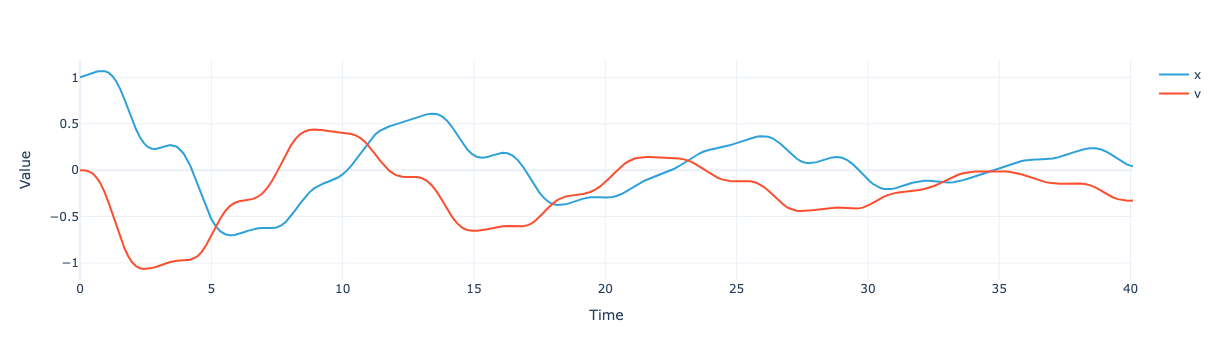

In [50]:
sol.visualize()

In [51]:
#| hide
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.sparse as sps
# from pymor.models.iosys import LTIModel
# import numpy as np
# import scipy.sparse as sps
# from pymor.core.logger import set_log_levels
# from pymor.algorithms.timestepping import ImplicitEulerTimeStepper

# set_log_levels({'pymor': 'WARNING'})

# k = 50
# n = 2 * k + 1

# E = sps.eye(n, format='lil')
# E[0, 0] = E[-1, -1] = 0.5
# E = E.tocsc()

# d0 = n * [-2 * (n - 1)**2]
# d1 = (n - 1) * [(n - 1)**2]
# A = sps.diags([d1, d0, d1], [-1, 0, 1], format='lil')
# A[0, 0] = A[-1, -1] = -n * (n - 1)
# A = A.tocsc()

# B = np.zeros((n, 2))
# B[:, 0] = 1
# B[0, 0] = B[-1, 0] = 0.5
# B[0, 1] = n - 1

# C = np.zeros((3, n))
# C[0, :n//3] = C[1, n//3:2*n//3] = C[2, 2*n//3:] = 1
# C /= C.sum(axis=1)[:, np.newaxis]

# fom = LTIModel.from_matrices(A, B, C, E=E)

# fom = fom.with_(T=4, time_stepper=ImplicitEulerTimeStepper(200))

# fom = fom.with_(solver_options=solver_options)

# sol = fom.solve(input='[sin(4 * t[0]), sin(6 * t[0])]')
# Y = fom.C.apply(sol).to_numpy()

# # Y = fom.output(input='[sin(4 * t[0]), sin(6 * t[0])]')

# fig, ax = plt.subplots()
# for i, y in enumerate(Y.T):
#     ax.plot(np.linspace(0, fom.T, fom.time_stepper.nt + 1), y, label=f'$y_{i+1}(t)$')
# _ = ax.set(xlabel='$t$', ylabel='$y(t)$', title='Output')
# _ = ax.legend()

# fom = fom.with_(
#     T=4, time_stepper=BDFTimeStepper(), num_values=200, 
#     A=fom.A.with_(solver_options=solver_options), 
#     B=fom.B.with_(solver_options=solver_options),
#     C=fom.C.with_(solver_options=solver_options),
#     E=fom.E.with_(solver_options=solver_options)
# )

# fom

# sol = fom.solve(input='[sin(4 * t[0]), sin(6 * t[0])]')
# Y = fom.C.apply(sol).to_numpy()

# # Y = fom.output(input='[sin(4 * t[0]), sin(6 * t[0])]')

# fig, ax = plt.subplots()
# for i, y in enumerate(Y.T):
#     ax.plot(np.linspace(0, fom.T, fom.num_values), y, label=f'$y_{i+1}(t)$')
# _ = ax.set(xlabel='$t$', ylabel='$y(t)$', title='Output')
# _ = ax.legend()

### StiffSwitchingTimeStepper -

In [52]:
#| export
class StiffSwitchingTimeStepper(TimeStepper):
    def __init__(self):
        # self.__auto_init(locals())
        pass
        
    def iterate(self, initial_time, end_time, initial_data, operator, rhs=None, mass=None, mu=None, num_values=None, solver_options=None):
        options = cvode_solver_options()['cvode_stiff_switching']
        if solver_options:
            options.update(solver_options)

        if initial_time < options['t_switch']:
            nonstiff_solver = AdamsTimeStepper()
            nonstiff = list(nonstiff_solver.iterate(initial_time, options['t_switch'], initial_data, operator, rhs=rhs, mass=mass, mu=mu, num_values=num_values))
            nonstiff_t_list = nonstiff_solver._t_list
            initial_data = nonstiff[-1][0]
            initial_time = nonstiff_t_list[-1]
        else:
            nonstiff = []
            nonstiff_t_list = []

        if end_time > options['t_switch']:
            stiff_solver = BDFTimeStepper()
            stiff = list(stiff_solver.iterate(options['t_switch'], end_time, initial_data, operator, rhs=rhs, mass=mass, mu=mu, num_values=num_values, solver_options=solver_options))
            stiff_t_list = stiff_solver._t_list            
        else:
            stiff = []
            stiff_t_list = []

        self._t_list = np.concatenate([nonstiff_t_list, stiff_t_list])
        
        return nonstiff + stiff

## Export - 

In [53]:
#| hide
import nbdev; nbdev.nbdev_export()